In [1]:
# pip install scikit-learn --upgrade

In [2]:
import numpy as np
import math as mt
from matplotlib import pyplot as plt
import sklearn
from scipy.stats import norm

### Model selection exercize

#### Black-hole binary formation channels with a Gaussian Mixture Model (GMM)

You want to figure out how many of formation channels are at play.

The strategy here is to fit a Gaussian Mixture Model: this model is a sum of $N$ gaussians each with mean $\mu_j$ and standard deviation $\sigma_j$ and weight $\alpha_j$:

$p(x_i|\theta) = \sum_{j=1}^N \alpha_j \mathcal{N}(\mu_j,\sigma_j) $

This depends on $3N-1$ parameters (not $3N$ because the sum of the $\alpha_j$ must be unity to ensure that this is a probability).

In [3]:
file_path = "data_files/formationchannels.npy"
data_bhb = np.load(file_path)
print(data_bhb.shape)

(2950, 1)


In [4]:
vec_data_bhb = data_bhb.transpose()
vec_data_bhb = vec_data_bhb.flatten()
print(vec_data_bhb.shape)

(2950,)


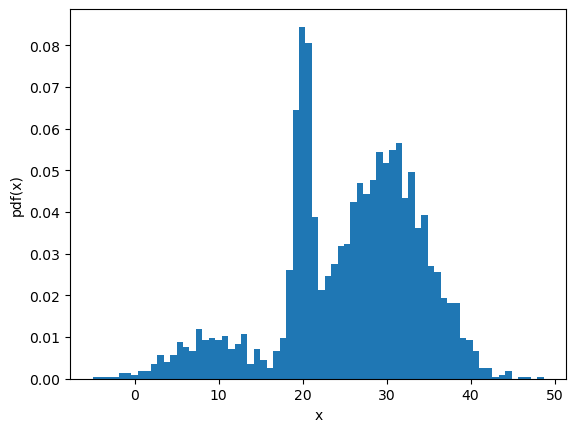

In [5]:
plt.hist(vec_data_bhb, bins=70, density=True)
plt.xlabel("x")
plt.ylabel("pdf(x)")
plt.show()

In [6]:
vec_fit = []
for i in range(1, 11):
  fit = sklearn.mixture.GaussianMixture(n_components=i).fit(data_bhb)
  vec_fit.append(fit)

In [7]:
fit_means = [vec_fit[pos].means_.flatten() for pos in range(len(vec_fit))]
fit_covs = [vec_fit[pos].covariances_.flatten() for pos in range(len(vec_fit))]
fit_weights = [vec_fit[pos].weights_ for pos in range(len(vec_fit))]
fit_AICs = [vec_fit[pos].aic(data_bhb) for pos in range(len(vec_fit))]

In [8]:
best = np.where(fit_AICs == min(fit_AICs))[0][0]
print("NUMBER OF COMPONENTS =",best+1)
print("means:",fit_means[best])
print("covariances:",fit_covs[best])
print("weights:",fit_weights[best])
print("AIC:",fit_AICs[best])
x_axis = np.linspace(min(data_bhb), max(data_bhb), 1000)

NUMBER OF COMPONENTS = 3
means: [20.05283694 30.12777783  9.09033281]
covariances: [ 1.14167809 24.08835035 21.78098637]
weights: [0.21467178 0.66911222 0.11621599]
AIC: 20083.505536921635


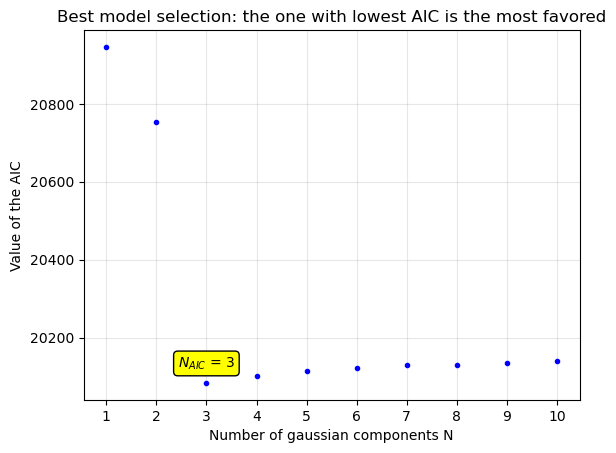

In [9]:
plt.plot(np.arange(1, 11), fit_AICs, ".b")
plt.xticks(np.arange(1, 11))
plt.xlabel("Number of gaussian components N")
plt.ylabel("Value of the AIC")
plt.title("Best model selection: the one with lowest AIC is the most favored")
plt.text(best+1, fit_AICs[best]+50, r"$N_{AIC}$ = "+str(best+1), ha="center", va="center", bbox={"facecolor": "yellow", "edgecolor": "black", "boxstyle": "round"})
plt.grid(alpha=0.3)
plt.show()

In [10]:
log_prob = vec_fit[best].score_samples(x_axis)  # Log-likelihood
pdf = np.exp(log_prob)  # Conversion into PDF

log_prob2 = vec_fit[1].score_samples(x_axis)
pdf2 = np.exp(log_prob2)

log_prob5 = vec_fit[4].score_samples(x_axis)
pdf5 = np.exp(log_prob5)

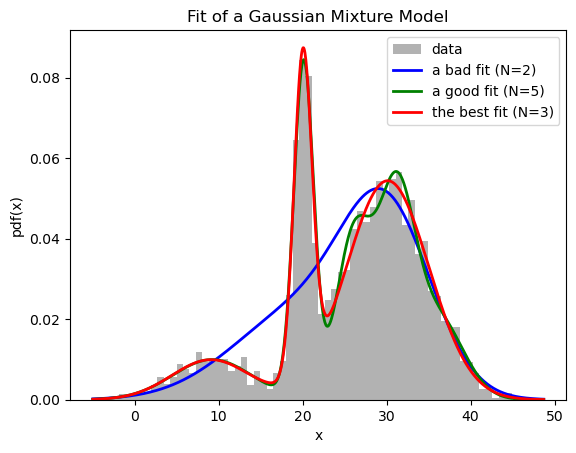

In [11]:
# Plotting data and estimated PDFs (a bad one, a good one and the best one)
plt.hist(vec_data_bhb, bins=70, density=True, alpha=0.6, color='gray', label="data")
plt.plot(x_axis, pdf2, color='blue', lw=2, label="a bad fit (N=2)")
plt.plot(x_axis, pdf5, color='green', lw=2, label="a good fit (N=5)")
plt.plot(x_axis, pdf, color='red', lw=2, label="the best fit (N={:.0f})".format(best+1))
plt.xlabel("x")
plt.ylabel("pdf(x)")
plt.title("Fit of a Gaussian Mixture Model")
plt.legend()
plt.show()

In [12]:
GMM_means = fit_means[best]
GMM_covariances = fit_covs[best]
GMM_weights = fit_weights[best]

grid = np.linspace(-10, 50, 1000)
dist_1 = norm(loc=GMM_means[0], scale=np.sqrt(GMM_covariances[0]))
dist_2 = norm(loc=GMM_means[1], scale=np.sqrt(GMM_covariances[1]))
dist_3 = norm(loc=GMM_means[2], scale=np.sqrt(GMM_covariances[2]))

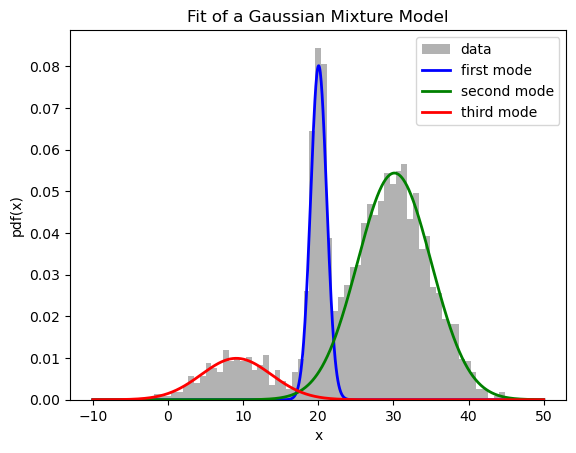

In [13]:
# Plotting which Gaussian mode corresponds to which part of the input dataset
plt.hist(vec_data_bhb, bins=70, density=True, alpha=0.6, color='gray', label="data")
plt.plot(grid, GMM_weights[0]*dist_1.pdf(grid), color='blue', lw=2, label="first mode")
plt.plot(grid, GMM_weights[1]*dist_2.pdf(grid), color='green', lw=2, label="second mode")
plt.plot(grid, GMM_weights[2]*dist_3.pdf(grid), color='red', lw=2, label="third mode")
plt.xlabel("x")
plt.ylabel("pdf(x)")
plt.title("Fit of a Gaussian Mixture Model")
plt.legend()
plt.show()